[*********************100%***********************]  1 of 1 completed


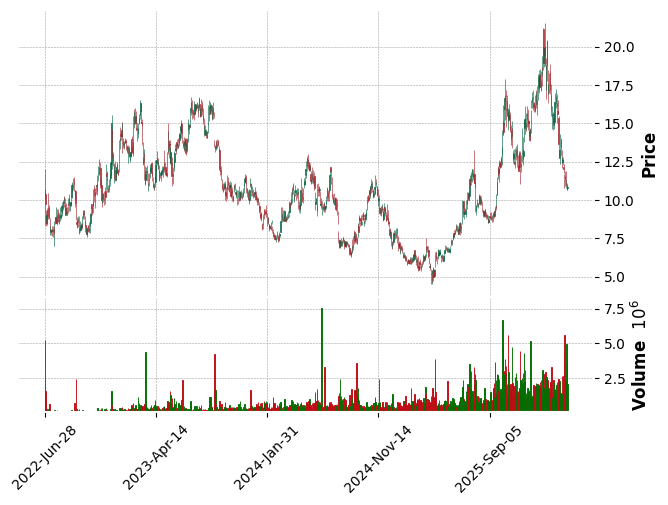

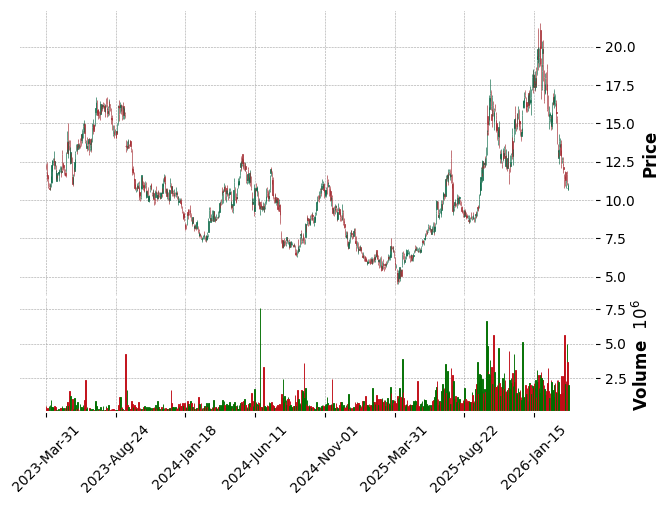

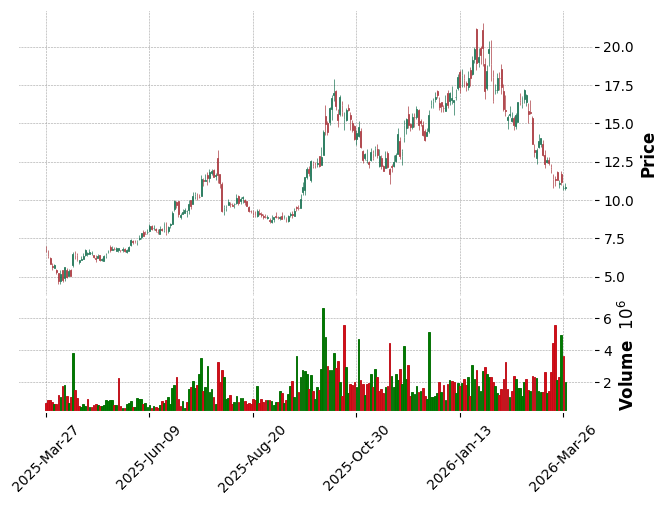

In [1]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-252:], type='candle', style='charles',volume=True)

In [2]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


26.97901


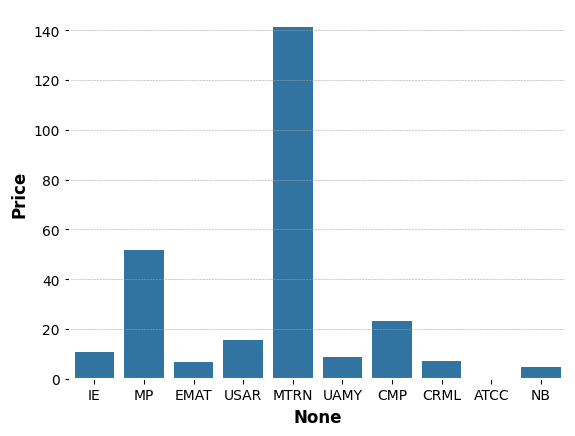

In [3]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [4]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [5]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [6]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Bullish (Net Buy): 47,159 shares


In [7]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-27 07:05:20
Shares of precious metals-related companies are trading higher amid a rebound in gold and silver prices. Also, concerns over prolonged elevated energy prices may help drive inflation hedging.

https://finnhub.io/api/news?id=10be65455cfe1a0c78c8f97f677f5d63e97137b5426a67256119d668aa2d5ce4

2026-03-26 06:56:13
Shares of precious metals-related companies are trading lower as continued military strikes in the Middle East conflict lead to dollar strength, oil price gains and inflation fears that could affect commodity prices and demand.

https://finnhub.io/api/news?id=8c6c08443668c4cf5aab8d84d60d1dbe23a28f0518427b455b334de318335526

2026-03-26 00:53:00
Top 3 Materials Stocks You'll Regret Missing In Q1
Oversold materials stocks present buying opportunities. RSI compares stock strength on up/down days, helps predict short term performance. RSI below 30 signals oversold. GROY, TMC, IE are oversold with RSI values of 29.8, 28.9, and N/A, respectively.
https://finnhub.io/api

Average Weighted EPS: -0.3037
Lower Standard Deviation: -0.5235654935078651
Upper Standard Deviation: -0.08383450649213495
Total Debt/Total Equity: 0.0811


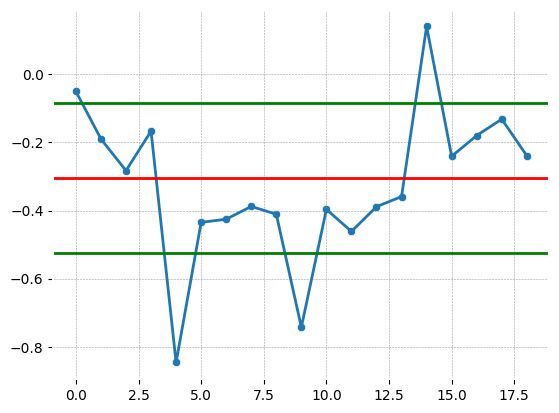

In [8]:
inflect = Fun.get_inflections()

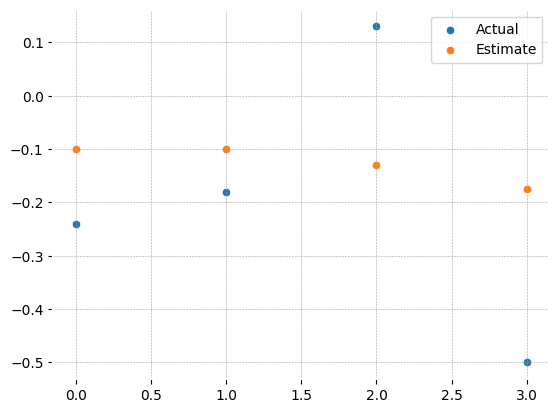

In [9]:
surprise = Fun.eps_surprise()

2021-12-31          NaN
2022-12-31   8440000.00
2023-12-31   3903000.00
2024-12-31   2901000.00
2025-12-31   3244000.00
Name: Total Revenue, dtype: float64
Revenue: [8440000. 3903000. 2901000. 3244000.]


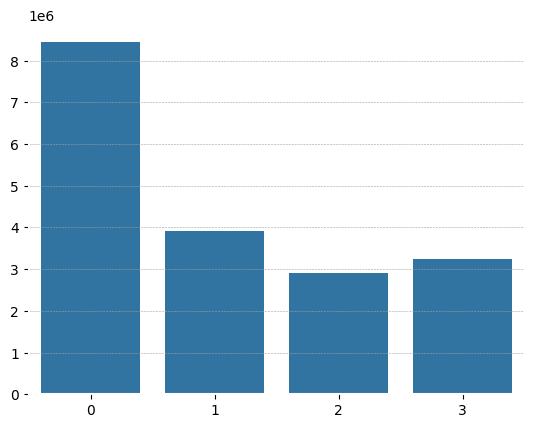

In [10]:
revenue = Fun.revenue_growth()

In [11]:
dcf = Fun.calculate_dcf()

Current FCF for IE: $-94,309,000.00
{'Current Price': 10.87,
 'Enterprise Value': -1363907971.32,
 'Intrinsic Price': -7.79,
 'Ticker': 'IE'}


In [12]:
Fun.analyze_turnaround()

--- Advanced Analysis: IE ---
Current Net Income: $-105,874,000 (Growing: True)
Net Debt / EBITDA: 1.27x (Lower is better)
Gross Margin: 65.29% (Previous: 64.91%)

SUMMARY: Efficiency is improving despite revenue trends.
